In [ ]:
import sys


sys.path.append('../../')

In [ ]:
from ml_factory.datasets.precompute_tokens import precompute_tokens
from ml_factory.utils import merge_parts_to_dir
from ml_factory import DATA_RAW_DIR, DATA_PROCESSED_DIR
from transformers import AutoTokenizer
import torch
from pathlib import Path
from ml_factory.datasets import PromptBERTDataset
from torch.utils.data import Subset, DataLoader
from ml_factory.datasets.sampler import SplitSampler
import numpy as np
import torch

from torch.utils.data import Subset, DataLoader
from transformers import AutoModelForSequenceClassification
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from ml_factory.datasets.test import build_parquet_file

In [ ]:
MODEL_NAME = "google/bert_uncased_L-4_H-256_A-4"

In [ ]:
odd_file = build_parquet_file(
    DATA_RAW_DIR / "odd_data.parquet"
)

print(odd_file)

c:\Users\Jivesh Gawde\Documents\NMIMS\sem3\FortexAI\Backend\ml_factory\notebooks\..\..\ml_factory\data\raw\odd_data.parquet


In [36]:
import pandas as pd

In [37]:
odd_df = pd.read_parquet(odd_file)

In [39]:

odd_df = odd_df[["text", "label"]]

In [40]:
odd_df.to_parquet(
    DATA_RAW_DIR / "odd_text_label.parquet",
    index=False
)

In [54]:
odd_df['label'].value_counts()

label
0    35197
1    18965
Name: count, dtype: int64

In [41]:
data_path = DATA_RAW_DIR / 'odd_text_label.parquet'
output_path = DATA_PROCESSED_DIR / '32_128_processed_odd'


In [ ]:
    
paths = precompute_tokens(dataset_path=data_path, 
                          out_path=output_path, 
                          tokenizer=AutoTokenizer,
                          pretrained_tokenizer="google/bert_uncased_L-4_H-256_A-4",
                          save_bytes=10_000_000,
                          token_chunk=True, 
                          stride=32, 
                          max_length=128)

Wrote 9880 items to c:\Users\Jivesh Gawde\Documents\NMIMS\sem3\FortexAI\Backend\ml_factory\notebooks\..\..\ml_factory\data\processed\32_128_processed_odd.part0.npz
Wrote 10059 items to c:\Users\Jivesh Gawde\Documents\NMIMS\sem3\FortexAI\Backend\ml_factory\notebooks\..\..\ml_factory\data\processed\32_128_processed_odd.part1.npz
Wrote 10050 items to c:\Users\Jivesh Gawde\Documents\NMIMS\sem3\FortexAI\Backend\ml_factory\notebooks\..\..\ml_factory\data\processed\32_128_processed_odd.part2.npz
Wrote 9928 items to c:\Users\Jivesh Gawde\Documents\NMIMS\sem3\FortexAI\Backend\ml_factory\notebooks\..\..\ml_factory\data\processed\32_128_processed_odd.part3.npz
Wrote 10041 items to c:\Users\Jivesh Gawde\Documents\NMIMS\sem3\FortexAI\Backend\ml_factory\notebooks\..\..\ml_factory\data\processed\32_128_processed_odd.part4.npz
Wrote 10024 items to c:\Users\Jivesh Gawde\Documents\NMIMS\sem3\FortexAI\Backend\ml_factory\notebooks\..\..\ml_factory\data\processed\32_128_processed_odd.part5.npz
Wrote 9897 i

In [ ]:
merge_parts_to_dir(part_paths=paths,
                   out_dir=output_path)

Merged 8 parts into directory c:\Users\Jivesh Gawde\Documents\NMIMS\sem3\FortexAI\Backend\ml_factory\notebooks\..\..\ml_factory\data\processed\32_128_processed_odd


WindowsPath('c:/Users/Jivesh Gawde/Documents/NMIMS/sem3/FortexAI/Backend/ml_factory/notebooks/../../ml_factory/data/processed/32_128_processed_odd')

In [42]:
dataset = PromptBERTDataset(output_path)

In [43]:
odd_loader = DataLoader(
    dataset,
    batch_size=100,
    shuffle=False
)

print("Number of odd-data batches:", len(odd_loader))

Number of odd-data batches: 745


In [44]:
save_dir = DATA_PROCESSED_DIR / "ensemble_classifier_mini"


save_dir.mkdir(parents=True, exist_ok=True)

In [45]:
MODEL_NAME = "google/bert_uncased_L-4_H-256_A-4"

MODEL_SAVE_DIR = DATA_PROCESSED_DIR / "ensemble_classifier_mini"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loaded_models = []

for i in range(1, 6):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    state_dict = torch.load(
        MODEL_SAVE_DIR / f"bert_{i}.pt",
        map_location=device
    )

    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    loaded_models.append(model)

print(f"Loaded {len(loaded_models)} models.")

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

Loaded 5 models.


In [46]:
import numpy as np
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

all_model_probabilities = []
odd_labels = None


for model_idx, model in enumerate(loaded_models):

    model.eval()

    model_probabilities = []
    model_labels = []


    with torch.no_grad():

        for batch in odd_loader:

            input_ids = batch["tokenized"].to(device)
            attention_mask = batch["attention_masks"].to(device)
            labels = batch["label"].to(device)


            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )


            # Probability of class 1
            probabilities = torch.softmax(
                outputs.logits,
                dim=1
            )[:, 1]


            model_probabilities.extend(
                probabilities.cpu().numpy()
            )

            model_labels.extend(
                labels.cpu().numpy()
            )


    all_model_probabilities.append(
        np.array(model_probabilities)
    )


    if odd_labels is None:
        odd_labels = np.array(model_labels)


    print(
        f"Model {model_idx + 1}: "
        f"{len(model_probabilities)} predictions"
    )

Model 1: 74429 predictions
Model 2: 74429 predictions
Model 3: 74429 predictions
Model 4: 74429 predictions
Model 5: 74429 predictions


In [47]:
model_probabilities_matrix = np.vstack(
    all_model_probabilities
)

print(
    "Probability matrix shape:",
    model_probabilities_matrix.shape
)

Probability matrix shape: (5, 74429)


In [48]:
ensemble_probabilities = np.mean(
    model_probabilities_matrix,
    axis=0
)

In [49]:
ensemble_predictions = (
    ensemble_probabilities >= 0.5
).astype(int)

In [50]:

odd_accuracy = accuracy_score(
    odd_labels,
    ensemble_predictions
)

odd_precision = precision_score(
    odd_labels,
    ensemble_predictions,
    zero_division=0
)

odd_recall = recall_score(
    odd_labels,
    ensemble_predictions,
    zero_division=0
)

odd_f1 = f1_score(
    odd_labels,
    ensemble_predictions,
    zero_division=0
)

odd_roc_auc = roc_auc_score(
    odd_labels,
    ensemble_probabilities
)

odd_pr_auc = average_precision_score(
    odd_labels,
    ensemble_probabilities
)


print("\nEnsemble Odd-Data Results")
print("-------------------------")
print(f"Accuracy : {odd_accuracy:.4f}")
print(f"Precision: {odd_precision:.4f}")
print(f"Recall   : {odd_recall:.4f}")
print(f"F1       : {odd_f1:.4f}")
print(f"ROC-AUC  : {odd_roc_auc:.4f}")
print(f"PR-AUC   : {odd_pr_auc:.4f}")


Ensemble Odd-Data Results
-------------------------
Accuracy : 0.8378
Precision: 0.9093
Recall   : 0.7439
F1       : 0.8183
ROC-AUC  : 0.9211
PR-AUC   : 0.9248


In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    predictions = (
        ensemble_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            odd_labels,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            odd_labels,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            odd_labels,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1
0,0.10,0.776578,0.914713,0.840005
1,0.15,0.814566,0.891190,0.851157
2,0.20,0.838996,0.870620,0.854516
3,0.25,0.856394,0.848710,0.852535
4,0.30,0.869213,0.827867,0.848037
5,0.35,0.880724,0.807079,0.842295
6,0.40,0.891619,0.786017,0.835495
7,0.45,0.901191,0.765639,0.827903
8,0.50,0.909319,0.743866,0.818313
9,0.55,0.916748,0.722285,0.807980


In [52]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    odd_labels,
    ensemble_probabilities
)

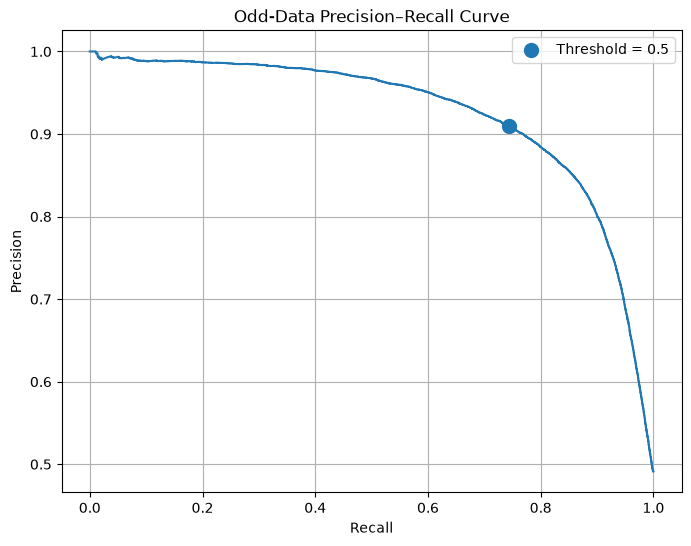

In [56]:
current_precision = precision_score(
    odd_labels,
    ensemble_predictions,
    zero_division=0
)

current_recall = recall_score(
    odd_labels,
    ensemble_predictions,
    zero_division=0
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)

plt.scatter(
    current_recall,
    current_precision,
    s=100,
    label="Threshold = 0.5"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Odd-Data Precision–Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    odd_labels,
    ensemble_predictions
)

print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

[[35158  2712]
 [ 9364 27195]]
TN: 35158
FP: 2712
FN: 9364
TP: 27195


In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

    preds = (ensemble_probabilities >= threshold).astype(int)

    precision = precision_score(
        odd_labels, preds, zero_division=0
    )
    recall = recall_score(
        odd_labels, preds, zero_division=0
    )
    f1 = f1_score(
        odd_labels, preds, zero_division=0
    )

    print(
        f"{threshold:.2f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

0.10 | Precision=0.7766 | Recall=0.9147 | F1=0.8400
0.15 | Precision=0.8146 | Recall=0.8912 | F1=0.8512
0.20 | Precision=0.8390 | Recall=0.8706 | F1=0.8545
0.25 | Precision=0.8564 | Recall=0.8487 | F1=0.8525
0.30 | Precision=0.8692 | Recall=0.8279 | F1=0.8480
0.35 | Precision=0.8807 | Recall=0.8071 | F1=0.8423
0.40 | Precision=0.8916 | Recall=0.7860 | F1=0.8355
0.45 | Precision=0.9012 | Recall=0.7656 | F1=0.8279
0.50 | Precision=0.9093 | Recall=0.7439 | F1=0.8183


In [60]:
fn_mask = (
    (odd_labels == 1) &
    (ensemble_predictions == 0)
)

fn_probabilities = ensemble_probabilities[fn_mask]

print(pd.Series(fn_probabilities).describe())

count    9364.000000
mean        0.212066
std         0.154757
min         0.003323
25%         0.063536
50%         0.196041
75%         0.348231
max         0.499954
dtype: float64


In [61]:
print(
    "FN probability percentiles:",
    np.percentile(
        fn_probabilities,
        [0, 10, 25, 50, 75, 90, 100]
    )
)

FN probability percentiles: [0.00332347 0.01991572 0.06353598 0.19604146 0.34823062 0.44076814
 0.49995351]
